In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import torch
from pathlib import Path
from copy import deepcopy

import shimnet

In [2]:
from enum import Enum

class PeaksParametersNames(Enum):
    tff_lin = "position_hz"
    thf_lin = "height"
    twf_lin = "width_hz"
    trf_lin = "gaussian_fraction"

    @classmethod
    def keys(cls):
        return [member.value for member in cls]
    
    @classmethod
    def values(cls):
        return [member.name for member in cls]

class SpectrumPeaksParser:
    def __init__(self,
        alias_position_hz = None,
        alias_height = None,
        alias_width_hz = None,
        alias_gaussian_fraction = None,
        default_position_hz = None,
        default_height = None,
        default_width_hz = None,
        default_gaussian_fraction = 0.,
        ):
        self.alias_position_hz = alias_position_hz if alias_position_hz is not None else "position_hz"
        self.alias_height = alias_height if alias_height is not None else "height"
        self.alias_width_hz = alias_width_hz if alias_width_hz is not None else "width_hz"
        self.alias_gaussian_fraction = alias_gaussian_fraction if alias_gaussian_fraction is not None else "gaussian_fraction"
        self.default_position_hz = default_position_hz
        self.default_height = default_height
        self.default_width_hz = default_width_hz
        self.default_gaussian_fraction = default_gaussian_fraction

    def transform_single_peak(self, peak: dict) -> dict:
        parsed_peak = {
            PeaksParametersNames("position_hz").name: peak.get(self.alias_position_hz, self.default_position_hz),
            PeaksParametersNames("height").name: peak.get(self.alias_height, self.default_height),
            PeaksParametersNames("width_hz").name: peak.get(self.alias_width_hz, self.default_width_hz),
            PeaksParametersNames("gaussian_fraction").name: peak.get(self.alias_gaussian_fraction, self.default_gaussian_fraction),
        }
        # Validate and convert other peak parameters
        for k, v in parsed_peak.items():
            if v is None:
                raise ValueError(f"Peak parameter '{k}' is None.")
            parsed_peak[k] = torch.atleast_1d(torch.tensor(v, dtype=torch.float32))
        return parsed_peak

    def transform(self, spectrum_peaks: list[dict]) -> list[dict]:
        parsed_peaks = []
        for peak in spectrum_peaks:
            parsed_peaks.append(self.transform_single_peak(peak))
        return parsed_peaks


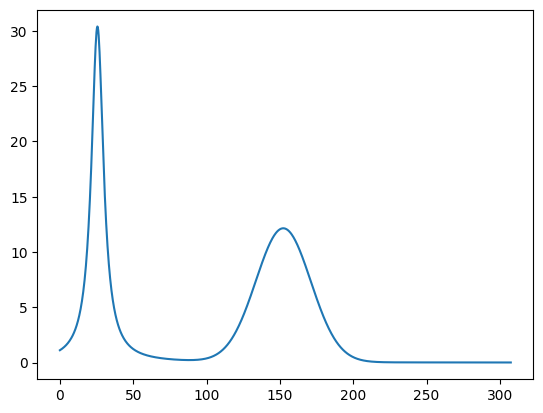

In [3]:
spectrum_peaks = [
    {
        "name": "Peak 1",
        "height": 30.4,
        "position_hz": 25.6,
        "width_hz": 5.0,
    },
    {
        "name": "Peak 2",
        "height": 12.1,
        "position_hz": 152.3,
        "width_hz": 22.0,
        "gaussian_fraction": 1.0,
    }
]
pd.DataFrame(spectrum_peaks).to_csv("data/substance1.csv", index=False)

parser = SpectrumPeaksParser()
frequencies = torch.arange(1024) * 0.30048  # Example frequency axis from 0 to 600 Hz with 1 Hz step

substance_peaks_data = parser.transform(spectrum_peaks)
substance_spectrum = shimnet.generators.spectrum_from_peaks_data(substance_peaks_data, frequencies)
plt.plot(frequencies.numpy(), substance_spectrum[0].numpy())

In [4]:
SPECTROMETER_FREQUENCY_MHZ = 600.0
FREQUENCY_PPM_START = -2.01456
FREQUENCY_N_STEPS = 32_767
FREQUENCY_PPM_STEP = (14.0151 - FREQUENCY_PPM_START) / (FREQUENCY_N_STEPS - 1)
frequency_ppm = FREQUENCY_PPM_START + FREQUENCY_PPM_STEP * torch.arange(FREQUENCY_N_STEPS)
frequency_hz = frequency_ppm * SPECTROMETER_FREQUENCY_MHZ

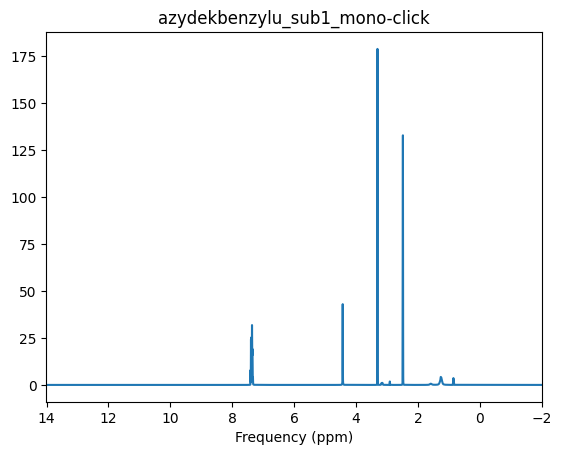

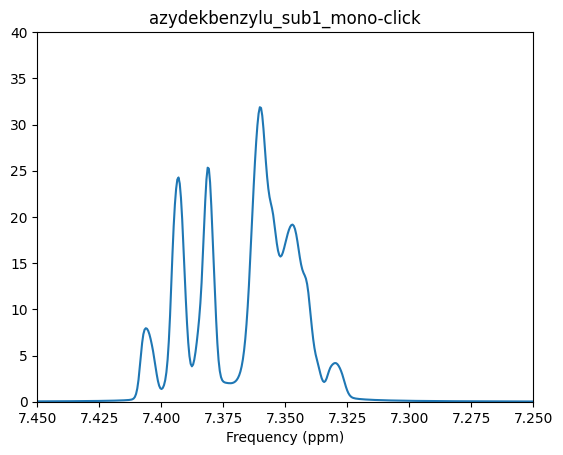

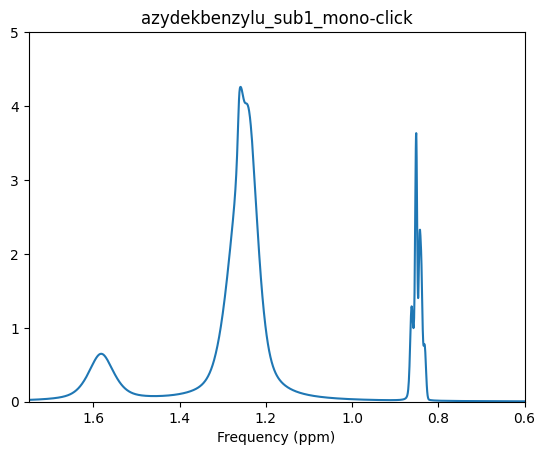

In [5]:
file_path = Path("data/processed_spectra/azydekbenzylu_sub1_mono-click.csv")
output_file_path = Path(f"data/output/{file_path.stem}.csv")
output_file_path.parent.mkdir(parents=True, exist_ok=True)

spectrum_peaks = pd.read_csv(file_path)

spectrum_peaks = spectrum_peaks.to_dict(orient="records")
substance_peaks_data = parser.transform(spectrum_peaks)

substance_spectrum = shimnet.generators.spectrum_from_peaks_data(substance_peaks_data, frequency_hz)

plt.plot(frequency_ppm.numpy(), substance_spectrum[0].numpy())
plt.title(file_path.stem)
plt.xlim(frequency_ppm.max(), frequency_ppm.min())
plt.xlabel("Frequency (ppm)")

plt.figure()
plt.plot(frequency_ppm.numpy(), substance_spectrum[0].numpy())
plt.title(file_path.stem)
plt.xlim(7.45, 7.25)
plt.ylim(0, 40)
plt.xlabel("Frequency (ppm)")


plt.figure()
plt.plot(frequency_ppm.numpy(), substance_spectrum[0].numpy())
plt.title(file_path.stem)
plt.xlim(1.75, 0.6)
plt.ylim(0, 5)
plt.xlabel("Frequency (ppm)")


np.savetxt(output_file_path, np.stack([frequency_ppm.numpy(), frequency_hz.numpy()], axis=1))


In [6]:
def get_peaks(multiplet_file_path, N_peaks=5):
    df = pd.read_csv(multiplet_file_path)
    df["singlet_name"] = df["multiplet_name"] + "/" + df["peak_in_multiplet"].astype(str)
    peaks_rows = df.sample(N_peaks)

    return peaks_rows

In [7]:
peaks_rows = get_peaks("/scratch/mbuk/nmr/projects/01_shimator/shimnet/development/data/processed_spectra/mieszanina_po_reakcji_2.csv", N_peaks=10)

In [17]:
from shimnet.generators import random_uniform_vector, random_loguniform_vector, RngGetter
from typing import Optional

In [14]:
df = pd.read_csv("/scratch/mbuk/nmr/projects/01_shimator/shimnet/development/data/processed_spectra/mieszanina_po_reakcji_2.csv")

In [45]:
class PeaksParametersFromSinglets:
    def __init__(self,
        singlets_files: list[pd.DataFrame],
        number_of_signals_min: int = 5,
        number_of_signals_max: int = 20,
        use_original_position: bool = True,
        position_hz_min: Optional[float] = None,
        position_hz_max: Optional[float] = None,
        position_hz_change_min: float = 0.0,
        position_hz_change_max: float = 0.0,
        use_original_width: bool = True,
        width_hz_min: float = 0.2,
        width_hz_max: float = 2.0,
        width_factor_min: float = 1.0,
        width_factor_max: float = 1.0,
        width_hz_change_min: float = 0.0,
        width_hz_change_max: float = 0.0,
        use_original_height: bool = True,
        height_min: float = 0.1,
        height_max: float = 10.0,
        height_factor_min: float = 1.0,
        height_factor_max: float = 1.0,
        height_change_min: float = 0.0,
        height_change_max: float = 0.0,
        use_original_gaussian_fraction: bool = True,
        gaussian_fraction_min: float = 0.0,
        gaussian_fraction_max: float = 1.0,
        gaussian_fraction_change_min: float = 0.0,
        gaussian_fraction_change_max: float = 0.0,
        seed=42
    ):
        self.peaks_rows = pd.concat([pd.read_csv(f) for f in singlets_files], ignore_index=True)
        
        # position
        self.use_original_position = use_original_position
        self.position_hz_min = position_hz_min
        self.position_hz_max = position_hz_max
        self.position_hz_change_min = position_hz_change_min
        self.position_hz_change_max = position_hz_change_max
        # width
        self.use_original_width = use_original_width
        self.width_hz_min = width_hz_min
        self.width_hz_max = width_hz_max
        self.width_factor_min = width_factor_min
        self.width_factor_max = width_factor_max
        self.width_hz_change_min = width_hz_change_min
        self.width_hz_change_max = width_hz_change_max
        # height
        self.use_original_height = use_original_height
        self.height_min = height_min
        self.height_max = height_max
        self.height_factor_min = height_factor_min
        self.height_factor_max = height_factor_max
        self.height_change_min = height_change_min
        self.height_change_max = height_change_max
        # gaussian fraction
        self.use_original_gaussian_fraction = use_original_gaussian_fraction
        self.gaussian_fraction_min = gaussian_fraction_min
        self.gaussian_fraction_max = gaussian_fraction_max
        self.gaussian_fraction_change_min = gaussian_fraction_change_min
        self.gaussian_fraction_change_max = gaussian_fraction_change_max

        self.rng_getter = RngGetter(seed=seed)

    def set_tff_range(self, tff_min, tff_max):
        self.position_hz_min = tff_min
        self.position_hz_max = tff_max

    def __call__(self, seed=None) -> list[dict]:
        # rng = self.rng_getter.get_rng(seed=seed)

        number_of_signals = torch.randint(
            low=self.number_of_signals_min,
            high=self.number_of_signals_max + 1,
            size=[],
            generator=rng
        )
        selected_peaks = self.peaks_rows.sample(n=number_of_signals.item(), random_state=seed)

        multiplet_data = {}
        # position
        if self.use_original_position:
            multiplet_data[PeaksParametersNames.position_hz.value] = torch.tensor(selected_peaks["position_hz"].values, dtype=torch.float32) + random_uniform_vector(self.position_hz_change_min, self.position_hz_change_max, size=len(selected_peaks))
        else:
            multiplet_data[PeaksParametersNames.position_hz.value] = random_uniform_vector(self.position_hz_min, self.position_hz_max, size=len(selected_peaks))
        # width
        if self.use_original_width:
            multiplet_data[PeaksParametersNames.width_hz.value] = torch.tensor(selected_peaks["width_hz"].values, dtype=torch.float32) * random_uniform_vector(self.width_factor_min, self.width_factor_max, size=len(selected_peaks)) + random_uniform_vector(self.width_hz_change_min, self.width_hz_change_max, size=len(selected_peaks))
        else:
            multiplet_data[PeaksParametersNames.width_hz.value] = random_loguniform_vector(self.width_hz_min, self.width_hz_max, size=len(selected_peaks))
        # height
        if self.use_original_height:
            multiplet_data[PeaksParametersNames.height.value] = torch.tensor(selected_peaks["height"].values, dtype=torch.float32) * random_uniform_vector(self.height_factor_min, self.height_factor_max, size=len(selected_peaks)) + random_uniform_vector(self.height_change_min, self.height_change_max, size=len(selected_peaks))
        else:
            multiplet_data[PeaksParametersNames.height.value] = random_loguniform_vector(self.height_min, self.height_max, size=len(selected_peaks))
        # gaussian fraction
        if self.use_original_gaussian_fraction:
            multiplet_data[PeaksParametersNames.gaussian_fraction.value] = torch.clamp(torch.tensor(selected_peaks["gaussian_fraction"].values, dtype=torch.float32) + random_uniform_vector(self.gaussian_fraction_change_min, self.gaussian_fraction_change_max, size=len(selected_peaks)), 0.0, 1.0)
        else:
            multiplet_data[PeaksParametersNames.gaussian_fraction.value] = random_uniform_vector(self.gaussian_fraction_min, self.gaussian_fraction_max, size=len(selected_peaks))

        return [multiplet_data]

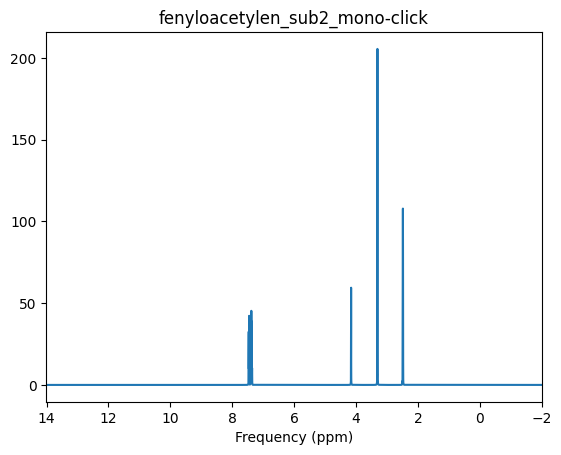

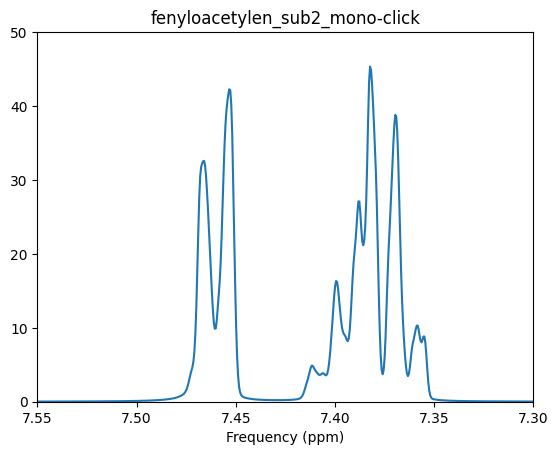

In [6]:
file_path = Path("data/processed_spectra/fenyloacetylen_sub2_mono-click.csv")
output_file_path = Path(f"data/output/{file_path.stem}.csv")
output_file_path.parent.mkdir(parents=True, exist_ok=True)

spectrum_peaks = pd.read_csv(file_path)


spectrum_peaks = spectrum_peaks.to_dict(orient="records")
substance_peaks_data = parser.transform(spectrum_peaks)

substance_spectrum = shimnet.generators.spectrum_from_peaks_data(substance_peaks_data, frequency_hz)

plt.plot(frequency_ppm.numpy(), substance_spectrum[0].numpy())
plt.title(file_path.stem)
plt.xlim(frequency_ppm.max(), frequency_ppm.min())
plt.xlabel("Frequency (ppm)")

plt.figure()
plt.plot(frequency_ppm.numpy(), substance_spectrum[0].numpy())
plt.title(file_path.stem)
plt.xlim(7.55, 7.3)
plt.ylim(0, 50)
plt.xlabel("Frequency (ppm)")


np.savetxt(output_file_path, np.stack([frequency_ppm.numpy(), frequency_hz.numpy()], axis=1))



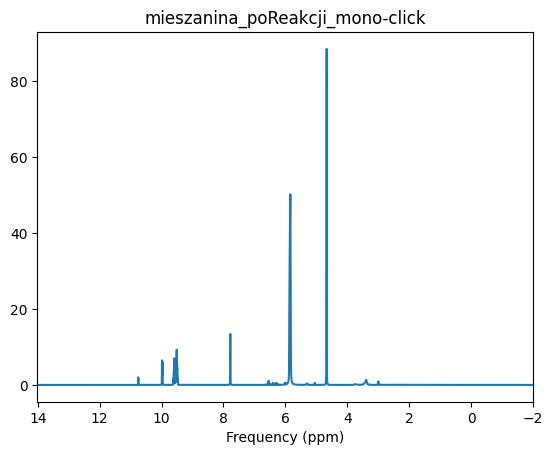

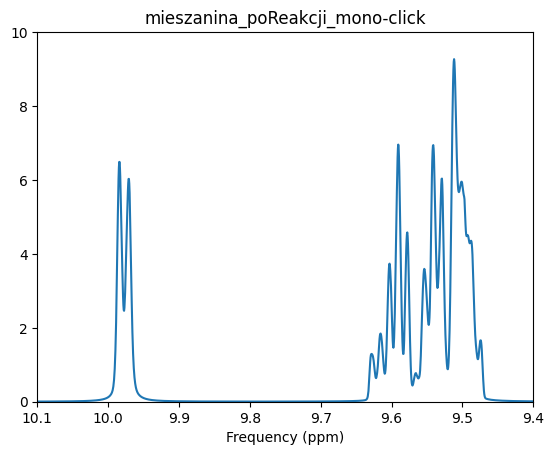

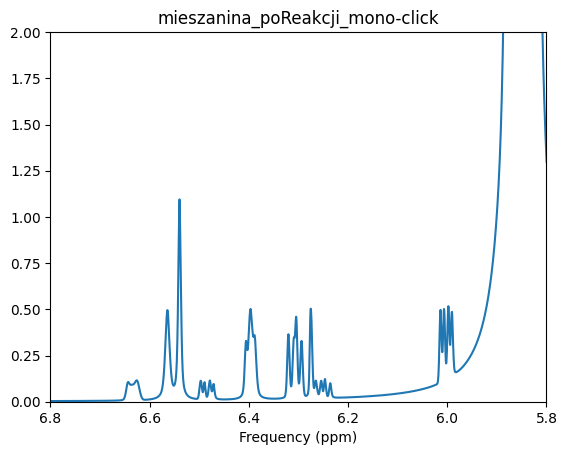

In [7]:
file_path = Path("data/processed_spectra/mieszanina_poReakcji_mono-click.csv")
output_file_path = Path(f"data/output/{file_path.stem}.csv")
output_file_path.parent.mkdir(parents=True, exist_ok=True)

spectrum_peaks = pd.read_csv(file_path)


spectrum_peaks = spectrum_peaks.to_dict(orient="records")
substance_peaks_data = parser.transform(spectrum_peaks)

substance_spectrum = shimnet.generators.spectrum_from_peaks_data(substance_peaks_data, frequency_hz)

plt.plot(frequency_ppm.numpy(), substance_spectrum[0].numpy())
plt.title(file_path.stem)
plt.xlim(frequency_ppm.max(), frequency_ppm.min())
plt.xlabel("Frequency (ppm)")

plt.figure()
plt.plot(frequency_ppm.numpy(), substance_spectrum[0].numpy())
plt.title(file_path.stem)
plt.xlim(10.1, 9.4)
plt.ylim(0, 10)
plt.xlabel("Frequency (ppm)")

plt.figure()
plt.plot(frequency_ppm.numpy(), substance_spectrum[0].numpy())
plt.title(file_path.stem)
plt.xlim(6.8, 5.8)
plt.ylim(0, 2)
plt.xlabel("Frequency (ppm)")


np.savetxt(output_file_path, np.stack([frequency_ppm.numpy(), frequency_hz.numpy()], axis=1))



In [ ]:
def csv_file_to_multiplets_dict(file_path: str) -> list[dict]:
    peaks_data = pd.read_csv(file_path)
    multiplets = {k: v.drop(columns="multiplet_name").to_dict(orient='list') for k, v in peaks_data.groupby("multiplet_name")}
    return multiplets

def csv_file_to_singlets_dict(file_path: str) -> dict:
    peaks_data = pd.read_csv(file_path)
    singlets = {k: v.drop(columns="singlet_name").to_dict(orient='list') for k, v in peaks_data.groupby("singlet_name")}
    return singlets

def combine_multiplets(multiplets_list: list[dict]) -> dict:
    composed_multiplets = {}
    for multiplets in multiplets_list:
        for k, v in multiplets.items():
            if not k in composed_multiplets:
                composed_multiplets[k] = v
            else:
                composed_multiplets[k].extend(v)
    return composed_multiplets

1 tensor(3239.8560)
2 tensor(193.4999)
3 tensor(557.0400)
4 tensor(216.9600)
5 tensor(144.)
6 tensor(309.7800)
7 tensor(75.9600)
8 tensor(133.2600)
9 tensor(5.4600)
10 tensor(10.6201)
11 tensor(40.6201)
12 tensor(39.0598)
13 tensor(25.6201)
14 tensor(14.7000)
15 tensor(36.7200)
16 tensor(680.8198)
17 tensor(1015.9799)
18 tensor(203.8799)
19 tensor(459.1201)


Text(0.5, 0, 'Frequency (ppm)')

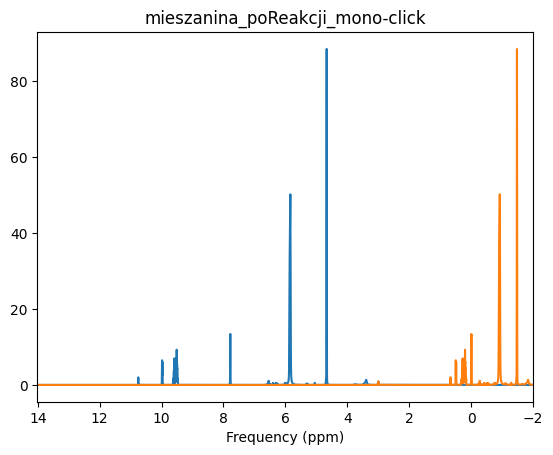

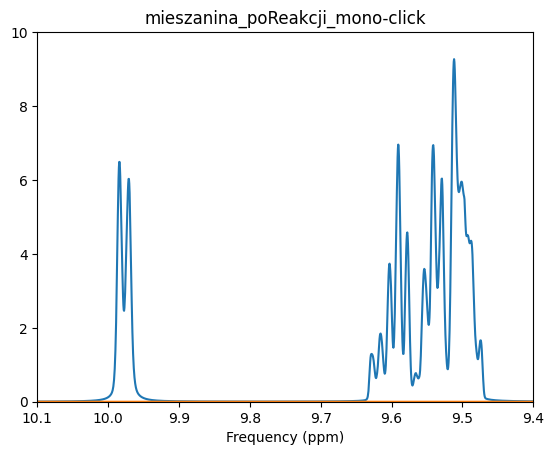

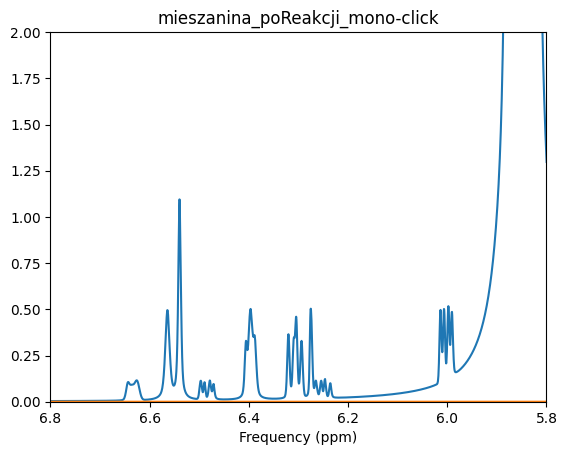

In [9]:
multiplets_standard = SpectrumPeaksParser().transform(sorted(csv_file_to_multiplets_dict("data/processed_spectra/mieszanina_poReakcji_mono-click.csv").values(), key=lambda x: min(x["position_hz"])))
multiplets_compressed = deepcopy(multiplets_standard)

max_tff = frequency_hz[0]
gap_hz = 100
for i in range(1, len(multiplets_compressed)):
    multiplet_gap = multiplets_compressed[i]["tff_lin"].min() - max_tff
    print(i, multiplet_gap)
    for j in range(i, len(multiplets_compressed)):
        multiplets_compressed[j]["tff_lin"] = multiplets_compressed[j]["tff_lin"] - max(0, multiplet_gap - gap_hz)
    max_tff = max(max_tff, multiplets_compressed[i]["tff_lin"].max())

substance_standard = shimnet.generators.spectrum_from_peaks_data(multiplets_standard, frequency_hz)
substance_compressed = shimnet.generators.spectrum_from_peaks_data(multiplets_compressed, frequency_hz)

plt.plot(frequency_ppm.numpy(), substance_standard[0].numpy())
plt.plot(frequency_ppm.numpy(), substance_compressed[0].numpy())
plt.title(file_path.stem)
plt.xlim(frequency_ppm.max(), frequency_ppm.min())
plt.xlabel("Frequency (ppm)")

plt.figure()
plt.plot(frequency_ppm.numpy(), substance_standard[0].numpy())
plt.plot(frequency_ppm.numpy(), substance_compressed[0].numpy())
plt.title(file_path.stem)
plt.xlim(10.1, 9.4)
plt.ylim(0, 10)
plt.xlabel("Frequency (ppm)")

plt.figure()
plt.plot(frequency_ppm.numpy(), substance_standard[0].numpy())
plt.plot(frequency_ppm.numpy(), substance_compressed[0].numpy())
plt.title(file_path.stem)
plt.xlim(6.8, 5.8)
plt.ylim(0, 2)
plt.xlabel("Frequency (ppm)")



In [10]:
multiplets_standard

[{'tff_lin': tensor([1805.7600, 1799.2800, 1794.8400, 1792.0800, 1787.7000]),
  'thf_lin': tensor([0.3000, 0.8500, 0.4600, 0.3800, 0.2200]),
  'twf_lin': tensor([3.0800, 2.7000, 1.8000, 2.5900, 2.3900]),
  'trf_lin': tensor([0.8929, 1.0000, 1.0000, 0.5917, 0.6329])},
 {'tff_lin': tensor([2044.6801, 2031.1200]),
  'thf_lin': tensor([0.7200, 0.7300]),
  'twf_lin': tensor([28.9300,  9.1900]),
  'trf_lin': tensor([0.3584, 1.0000])},
 {'tff_lin': tensor([2238.1799]),
  'thf_lin': tensor([0.2000]),
  'twf_lin': tensor([22.9700]),
  'trf_lin': tensor([0.3497])},
 {'tff_lin': tensor([2811.3000, 2809.4399, 2807.6399, 2802.7800, 2800.8601, 2799.0000,
          2797.0801, 2795.2200]),
  'thf_lin': tensor([ 0.6100,  0.6600,  0.3900, 13.0100, 35.2600, 52.3300, 38.6200, 14.3400]),
  'twf_lin': tensor([1.4900, 1.3300, 1.2600, 1.4200, 1.8100, 1.8400, 1.7800, 1.4300]),
  'trf_lin': tensor([0.8475, 0.6494, 0.6667, 0.4651, 0.7937, 0.8130, 0.9615, 0.5682])},
 {'tff_lin': tensor([3028.2600]),
  'thf_lin': 

In [11]:
multiplets_standard[0]

{'tff_lin': tensor([1805.7600, 1799.2800, 1794.8400, 1792.0800, 1787.7000]),
 'thf_lin': tensor([0.3000, 0.8500, 0.4600, 0.3800, 0.2200]),
 'twf_lin': tensor([3.0800, 2.7000, 1.8000, 2.5900, 2.3900]),
 'trf_lin': tensor([0.8929, 1.0000, 1.0000, 0.5917, 0.6329])}

In [12]:
spectrum_peaks = pd.read_csv(file_path)


- read csv data
- transform data to multiplets (dict)
- apply randomness to multiplets
- create 

In [13]:
class MultipletsLibrary:
    def __init__(self, csv_files_paths: list[str], peak_data_parser: SpectrumPeaksParser = None, return_name=False):
        self.csv_files_paths = csv_files_paths
        self.multiplets_data = {}
        self.peak_data_parser = peak_data_parser
        for file_path in csv_files_paths:
            self.multiplets_data.update(self._get_multiplet_data_from_file(file_path))
        
        self.names = sorted(self.multiplets_data.keys())
        self.return_name = return_name

    def _get_multiplet_data_from_file(self, file_path: str) -> dict:
        multiplets = csv_file_to_multiplets_dict(Path(file_path)) # list[dict]
        return {f"{file_path}/{k}": self.peak_data_parser.transform([v])[0] for k, v in multiplets.items()}

    def get_by_name(self, name: str) -> dict:
        return self.multiplets_data.get(name, None)
    
    def __getitem__(self, idx: int) -> dict:
        name = self.names[idx]
        multiplet_data = deepcopy(self.multiplets_data[name])
        if self.return_name:
            return name, multiplet_data
        return multiplet_data
    
    def __len__(self):
        return len(self.multiplets_data)

class SectraLibrary(MultipletsLibrary):
    def _get_multiplet_data_from_file(self, file_path: str) -> dict:
        multiplets = csv_file_to_multiplets_dict(Path(file_path)) # dict[dict]
        combined_multiplet = combine_multiplets(multiplets.values()) # dict
        return {f"{file_path}": self.peak_data_parser.transform([combined_multiplet])[0]}

In [14]:
multiplets_library = MultipletsLibrary(sorted(Path("data/processed_spectra").glob("*.csv")), SpectrumPeaksParser())
print(multiplets_library.names)
print(multiplets_library[0])

['data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M1', 'data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M2', 'data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M3', 'data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M4', 'data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M5', 'data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M6', 'data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M7', 'data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M8', 'data/processed_spectra/azydekbenzylu_sub1_mono-click.csv/M9', 'data/processed_spectra/fenyloacetylen_sub2_mono-click.csv/M1', 'data/processed_spectra/fenyloacetylen_sub2_mono-click.csv/M2', 'data/processed_spectra/fenyloacetylen_sub2_mono-click.csv/M3', 'data/processed_spectra/fenyloacetylen_sub2_mono-click.csv/M4', 'data/processed_spectra/fenyloacetylen_sub2_mono-click.csv/M5', 'data/processed_spectra/mieszanina_poReakcji_mono-click.csv/M1', 'data/processed_spectra/mieszanina_poReakcji_mo

In [15]:
spectra_library = SectraLibrary(sorted(Path("data/processed_spectra").glob("*.csv")), SpectrumPeaksParser())
print(spectra_library.names)
print(spectra_library[0])


['data/processed_spectra/azydekbenzylu_sub1_mono-click.csv', 'data/processed_spectra/fenyloacetylen_sub2_mono-click.csv', 'data/processed_spectra/mieszanina_poReakcji_mono-click.csv', 'data/processed_spectra/mieszanina_po_reakcji_2.csv']
{'tff_lin': tensor([4444.5601, 4443.2998, 4441.6802, 4438.8599, 4437.1802, 4436.0400,
        4434.8999, 4432.3799, 4431.0601, 4428.9600, 4428.1802, 4427.1001,
        4424.6401, 4417.6201, 4415.8799, 4413.0000, 4410.7202, 4408.9199,
        4407.2998, 4404.7202, 4402.0801, 4399.3198, 4397.7598, 4396.1401,
        2657.4600, 1983.6000, 1979.1600, 1903.7400, 1895.2200, 1886.6400,
        1743.4800, 1494.0601, 1492.2000, 1490.2800, 1488.4800, 1486.6200,
         949.0800,  763.6800,  757.1400,  755.4000,  743.8800,  517.5000,
         513.0000,  510.7800,  506.1600,  503.5800,  499.0200]), 'thf_lin': tensor([2.9500e+00, 6.4500e+00, 1.9200e+00, 6.0000e-01, 8.3400e+00, 1.4170e+01,
        1.0630e+01, 8.3000e-01, 4.3200e+00, 1.6170e+01, 9.8900e+00, 2.3700e+

In [16]:
from shimnet.generators import RngGetter, random_value, random_loguniform

class MultipletDataFromPeakListsGenerator:
    def __init__(self,
        multiplets_library,
        tff_min=None, #may be assigned after initialization if the original peak positions are not used
        tff_max=None, #may be assigned after initialization if the original peak positions are not used
        use_original_peak_position=True,
        number_of_signals_min=None, 
        number_of_signals_max=None,
        spectrum_width_factor_min=1, 
        spectrum_width_factor_max=1,
        multiplet_width_factor_min=1, 
        multiplet_width_factor_max=1,
        spectrum_height_factor_min=1, 
        spectrum_height_factor_max=1,
        multiplet_height_factor_min=1, 
        multiplet_height_factor_max=1,
        position_shift_min=0, 
        position_shift_max=0,
        gaussian_fraction_change_min=None, 
        gaussian_fraction_change_max=None,
        seed=42
        ):

        if (number_of_signals_min is None) != (number_of_signals_max is None):
            raise ValueError("Both number_of_signals_min and number_of_signals_max should be provided or both should be None.")

        self.multiplets_library = multiplets_library
        self.rng_getter = RngGetter(seed=seed)
        self.tff_min = tff_min
        self.tff_max = tff_max
        self.use_original_peak_position = use_original_peak_position
        self.number_of_signals_min = number_of_signals_min
        self.number_of_signals_max = number_of_signals_max
        self.spectrum_width_factor_min = spectrum_width_factor_min
        self.spectrum_width_factor_max = spectrum_width_factor_max
        self.multiplet_width_factor_min = multiplet_width_factor_min
        self.multiplet_width_factor_max = multiplet_width_factor_max
        self.spectrum_height_factor_min = spectrum_height_factor_min
        self.spectrum_height_factor_max = spectrum_height_factor_max
        self.multiplet_height_factor_min = multiplet_height_factor_min
        self.multiplet_height_factor_max = multiplet_height_factor_max
        self.position_shift_min = position_shift_min
        self.position_shift_max = position_shift_max
        self.gaussian_fraction_change_min = gaussian_fraction_change_min
        self.gaussian_fraction_change_max = gaussian_fraction_change_max

    def set_tff_range(self, tff_min, tff_max):
        self.tff_min = tff_min
        self.tff_max = tff_max

    def __call__(self, seed=None):
        if (not self.use_original_peak_position) and (self.tff_min is None or self.tff_max is None):
            raise ValueError("for use_original_peak_position=False, tff_min and tff_max must be set before calling the generator.")

        rng = self.rng_getter.get_rng(seed=seed)

        # select number of signals and their indices
        if self.number_of_signals_min is None:
            number_of_signals = len(self.multiplets_library)
            multiplets_indices = list(range(len(self.multiplets_library)))
        else:
            number_of_signals = torch.randint(
                self.number_of_signals_min, 
                self.number_of_signals_max + 1, 
                [], 
                generator=rng
            )
        
            multiplets_indices = torch.randint(
                0, 
                len(self.multiplets_library), 
                [number_of_signals], 
                generator=rng
            )
        
        # spectrum width and height factors
        spectrum_width_factor = random_loguniform(
            self.spectrum_width_factor_min, 
            self.spectrum_width_factor_max, 
            generator=rng
        )

        spectrum_height_factor = random_loguniform(
            self.spectrum_height_factor_min, 
            self.spectrum_height_factor_max, 
            generator=rng
        )

        # get and modify peaks parameters data
        peaks_parameters_data = [self.multiplets_library[idx] for idx in multiplets_indices]
        for peak_parameters in peaks_parameters_data:
            
            # position
            if not self.use_original_peak_position:
                new_position = random_value(self.tff_min, self.tff_max, generator=rng)
                peak_parameters["tff_lin"] = new_position
            else:
                position_shift = random_value(self.position_shift_min, self.position_shift_max, generator=rng)
                peak_parameters["tff_lin"] = peak_parameters["tff_lin"] + position_shift

            # width
            multiplet_width_factor = random_loguniform(
                self.multiplet_width_factor_min, 
                self.multiplet_width_factor_max, 
                generator=rng
            )
            peak_parameters["twf_lin"] = peak_parameters["twf_lin"] * spectrum_width_factor * multiplet_width_factor

            # height
            multiplet_height_factor = random_loguniform(
                self.multiplet_height_factor_min, 
                self.multiplet_height_factor_max, 
                generator=rng
            )
            peak_parameters["thf_lin"] = peak_parameters["thf_lin"] * spectrum_height_factor * multiplet_height_factor

            # gaussian contribution
            if self.gaussian_fraction_change_min is not None:
                gaussian_contribution_shift = random_value(self.gaussian_fraction_change_min, self.gaussian_fraction_change_max, generator=rng)
                peak_parameters["trf_lin"] = torch.clip(peak_parameters["trf_lin"] + gaussian_contribution_shift, 0., 1.)

        return peaks_parameters_data

In [17]:
peak_params_generator1 = MultipletDataFromPeakListsGenerator(
    multiplets_library=spectra_library
)
peak_params_generator2 = MultipletDataFromPeakListsGenerator(
    multiplets_library=multiplets_library
)

peak_params_generator2 = MultipletDataFromPeakListsGenerator(
    multiplets_library=multiplets_library,
    number_of_signals_min=2,
    number_of_signals_max=5,
)

In [18]:
peak_params_generator2()

[{'tff_lin': tensor([3792.1799, 3785.8201, 3782.7000, 3776.2800]),
  'thf_lin': tensor([0.3400, 0.2700, 0.4100, 0.3000]),
  'twf_lin': tensor([1.6100, 1.4900, 1.6100, 1.6700]),
  'trf_lin': tensor([0.8130, 0.5618, 0.6494, 0.8621])},
 {'tff_lin': tensor([517.5000, 513.0000, 510.7800, 506.1600, 503.5800, 499.0200]),
  'thf_lin': tensor([0.9400, 0.6700, 3.0000, 1.7100, 1.5500, 0.6900]),
  'twf_lin': tensor([2.2200, 4.2800, 1.5800, 1.6100, 1.7800, 2.1400]),
  'trf_lin': tensor([0.6024, 1.0000, 1.0000, 1.0000, 0.7519, 1.0000])},
 {'tff_lin': tensor([3923.8201]),
  'thf_lin': tensor([1.0800]),
  'twf_lin': tensor([1.8600]),
  'trf_lin': tensor([0.4132])},
 {'tff_lin': tensor([763.6800, 757.1400, 755.4000, 743.8800]),
  'thf_lin': tensor([1.4400, 0.2600, 0.7000, 3.2800]),
  'twf_lin': tensor([18.7400,  1.9000,  3.9300, 15.6500]),
  'trf_lin': tensor([0.5208, 0.3571, 0.9174, 0.4016])}]

In [ ]:
class SingletsLibrary(MultipletsLibrary): --- IGNORE ---
    def _get_multiplet_data_from_file(self, file_path: str) -> dict:
        peaks_data = pd.read_csv(Path(file_path))
        singlets_data = {}
        for _, row in peaks_data.iterrows():
            singlet_name = f"{file_path}/{row['peak_name']}"
            singlet_dict = {
                PeaksParametersNames("position_hz").name: [row["position_hz"]],
                PeaksParametersNames("height").name: [row["height"]],
                PeaksParametersNames("width_hz").name: [row["width_hz"]],
                PeaksParametersNames("gaussian_fraction").name: [row.get("gaussian_fraction", 0.)],
            }
            singlets_data[singlet_name] = self.peak_data_parser.transform([singlet_dict])[0]
        return singlets_data


In [ ]:
class MultipletsLibrary:
    def __init__(self, csv_files_paths: list[str], peak_data_parser: SpectrumPeaksParser = None, return_name=False):
        self.csv_files_paths = csv_files_paths
        self.multiplets_data = {}
        self.peak_data_parser = peak_data_parser
        for file_path in csv_files_paths:
            self.multiplets_data.update(self._get_multiplet_data_from_file(file_path))
        
        self.names = sorted(self.multiplets_data.keys())
        self.return_name = return_name

    def _get_multiplet_data_from_file(self, file_path: str) -> dict:
        multiplets = csv_file_to_multiplets_dict(Path(file_path)) # list[dict]
        return {f"{file_path}/{k}": self.peak_data_parser.transform([v])[0] for k, v in multiplets.items()}

    def get_by_name(self, name: str) -> dict:
        return self.multiplets_data.get(name, None)
    
    def __getitem__(self, idx: int) -> dict:
        name = self.names[idx]
        multiplet_data = deepcopy(self.multiplets_data[name])
        if self.return_name:
            return name, multiplet_data
        return multiplet_data
    
    def __len__(self):
        return len(self.multiplets_data)


In [53]:
class PeaksParametersFromSinglets:
    def __init__(self,
        singlets_files: list[pd.DataFrame],
        number_of_signals_min: int = 5,
        number_of_signals_max: int = 20,
        use_original_position: bool = True,
        position_hz_min: Optional[float] = None,
        position_hz_max: Optional[float] = None,
        position_hz_change_min: float = 0.0,
        position_hz_change_max: float = 0.0,
        use_original_width: bool = True,
        width_hz_min: float = 0.2,
        width_hz_max: float = 2.0,
        width_factor_min: float = 1.0,
        width_factor_max: float = 1.0,
        width_hz_change_min: float = 0.0,
        width_hz_change_max: float = 0.0,
        use_original_height: bool = True,
        height_min: float = 0.1,
        height_max: float = 10.0,
        height_factor_min: float = 1.0,
        height_factor_max: float = 1.0,
        height_change_min: float = 0.0,
        height_change_max: float = 0.0,
        use_original_gaussian_fraction: bool = True,
        gaussian_fraction_min: float = 0.0,
        gaussian_fraction_max: float = 1.0,
        gaussian_fraction_change_min: float = 0.0,
        gaussian_fraction_change_max: float = 0.0,
        seed=42
    ):
        self.peaks_rows = pd.concat([pd.read_csv(f) for f in singlets_files], ignore_index=True)
        
        # number of signals
        self.number_of_signals_min = number_of_signals_min
        self.number_of_signals_max = number_of_signals_max
        # position
        self.use_original_position = use_original_position
        self.position_hz_min = position_hz_min
        self.position_hz_max = position_hz_max
        self.position_hz_change_min = position_hz_change_min
        self.position_hz_change_max = position_hz_change_max
        # width
        self.use_original_width = use_original_width
        self.width_hz_min = width_hz_min
        self.width_hz_max = width_hz_max
        self.width_factor_min = width_factor_min
        self.width_factor_max = width_factor_max
        self.width_hz_change_min = width_hz_change_min
        self.width_hz_change_max = width_hz_change_max
        # height
        self.use_original_height = use_original_height
        self.height_min = height_min
        self.height_max = height_max
        self.height_factor_min = height_factor_min
        self.height_factor_max = height_factor_max
        self.height_change_min = height_change_min
        self.height_change_max = height_change_max
        # gaussian fraction
        self.use_original_gaussian_fraction = use_original_gaussian_fraction
        self.gaussian_fraction_min = gaussian_fraction_min
        self.gaussian_fraction_max = gaussian_fraction_max
        self.gaussian_fraction_change_min = gaussian_fraction_change_min
        self.gaussian_fraction_change_max = gaussian_fraction_change_max

        self.rng_getter = RngGetter(seed=seed)

    def set_tff_range(self, tff_min, tff_max):
        self.position_hz_min = tff_min
        self.position_hz_max = tff_max

    def __call__(self, seed=None) -> list[dict]:
        rng = self.rng_getter.get_rng(seed=seed)

        number_of_signals = torch.randint(
            low=self.number_of_signals_min,
            high=self.number_of_signals_max + 1,
            size=[],
            generator=rng
        )
        selected_peaks = self.peaks_rows.sample(n=number_of_signals.item(), random_state=seed)

        multiplet_data = {}
        # position
        if self.use_original_position:
            multiplet_data[PeaksParametersNames.position_hz.value] = torch.tensor(selected_peaks["position_hz"].values, dtype=torch.float32) + random_uniform_vector(self.position_hz_change_min, self.position_hz_change_max, size=len(selected_peaks))
        else:
            multiplet_data[PeaksParametersNames.position_hz.value] = random_uniform_vector(self.position_hz_min, self.position_hz_max, size=len(selected_peaks))
        # width
        if self.use_original_width:
            multiplet_data[PeaksParametersNames.width_hz.value] = torch.tensor(selected_peaks["width_hz"].values, dtype=torch.float32) * random_uniform_vector(self.width_factor_min, self.width_factor_max, size=len(selected_peaks)) + random_uniform_vector(self.width_hz_change_min, self.width_hz_change_max, size=len(selected_peaks))
        else:
            multiplet_data[PeaksParametersNames.width_hz.value] = random_loguniform_vector(self.width_hz_min, self.width_hz_max, size=len(selected_peaks))
        # height
        if self.use_original_height:
            multiplet_data[PeaksParametersNames.height.value] = torch.tensor(selected_peaks["height"].values, dtype=torch.float32) * random_uniform_vector(self.height_factor_min, self.height_factor_max, size=len(selected_peaks)) + random_uniform_vector(self.height_change_min, self.height_change_max, size=len(selected_peaks))
        else:
            multiplet_data[PeaksParametersNames.height.value] = random_loguniform_vector(self.height_min, self.height_max, size=len(selected_peaks))
        # gaussian fraction
        if self.use_original_gaussian_fraction:
            multiplet_data[PeaksParametersNames.gaussian_fraction.value] = torch.clamp(torch.tensor(selected_peaks["gaussian_fraction"].values, dtype=torch.float32) + random_uniform_vector(self.gaussian_fraction_change_min, self.gaussian_fraction_change_max, size=len(selected_peaks)), 0.0, 1.0)
        else:
            multiplet_data[PeaksParametersNames.gaussian_fraction.value] = random_uniform_vector(self.gaussian_fraction_min, self.gaussian_fraction_max, size=len(selected_peaks))

        return [multiplet_data]

In [56]:
peaks_params_generator1 = PeaksParametersFromSinglets(
    singlets_files=["data/processed_spectra/mieszanina_poReakcji_mono-click.csv"]
)

In [59]:
peaks_params_generator1(12)

[{'tff_lin': tensor([5690.2798, 5776.4399, 5760.1802, 5778.0000, 5746.5601, 3741.4800,
          2799.0000, 3776.2800, 5686.1401, 5768.3398, 5748.2402, 3765.6599,
          2795.2200, 3785.8201, 2797.0801, 5708.8198]),
  'twf_lin': tensor([1.4400, 1.8400, 1.1400, 1.0900, 1.7600, 1.4100, 1.8400, 1.6700, 1.9200,
          1.8900, 1.1900, 1.0600, 1.4300, 1.4900, 1.7800, 1.7000]),
  'thf_lin': tensor([ 0.6900,  0.9600,  0.7500,  0.5000,  4.1600,  0.0800, 52.3300,  0.3000,
           0.5600,  1.1100,  0.8400,  0.2400, 14.3400,  0.2700, 38.6200,  2.0100]),
  'trf_lin': tensor([0.8772, 1.0000, 0.7634, 0.6711, 0.9259, 0.5319, 0.8130, 0.8621, 0.6993,
          0.9804, 0.9804, 0.4310, 0.5682, 0.5618, 0.9615, 0.7634])}]